# 📱 Liquidity Stress Prediction Challenge - Starter Notebook

Welcome to the starter notebook for this challenge.

In this challenge, your goal is to build a machine learning model that predicts whether a customer is likely to experience liquidity stress, using historical mobile money behaviour.

This notebook walks through a simple end-to-end pipeline:

- Loading and exploring the data
- Preprocessing
- Training a baseline model
- Evaluating performance
- Generating predictions for submission

The baseline model used here is **Logistic Regression**, which is a good starting point for tabular classification problems.


In [2]:
# 📚 Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression


sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)


In [3]:
# 📥 Load the Data
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

SUBMISSION_TARGET = "Target"

# Create a sample submission template directly from the test IDs
sample_submission = pd.DataFrame({
    "ID": test["ID"],
    SUBMISSION_TARGET: 0.5
})

# Peek at the data
train.head()


,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highe

## 🔍 Exploratory Data Analysis (EDA)

Let’s explore the training data to understand the features and target.


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 184 entries, arpu to ID
dtypes: float64(134), int64(44), object(6)
memory usage: 56.2+ MB


In [5]:
train[train.isna().any(axis=1)]

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highe

In [6]:
train.dtypes

arpu                         float64
age                            int64
gender                        object
region                        object
smartphone                    object
                              ...   
m4_daily_avg_bal             float64
m5_daily_avg_bal             float64
m6_daily_avg_bal             float64
liquidity_stress_next_30d      int64
ID                            object
Length: 184, dtype: object

In [7]:
# Check missing values
missing_summary = train.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].head(20)


Series([], dtype: int64)

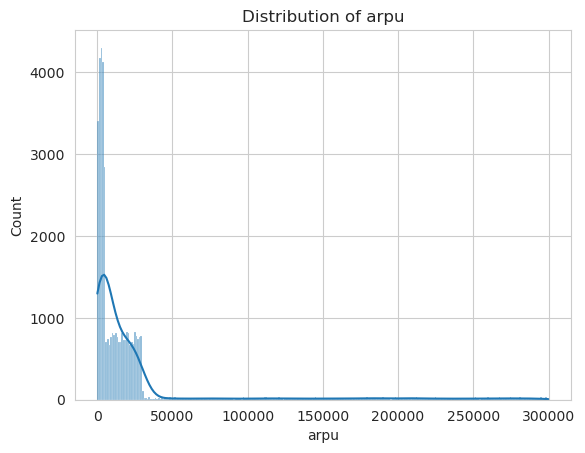

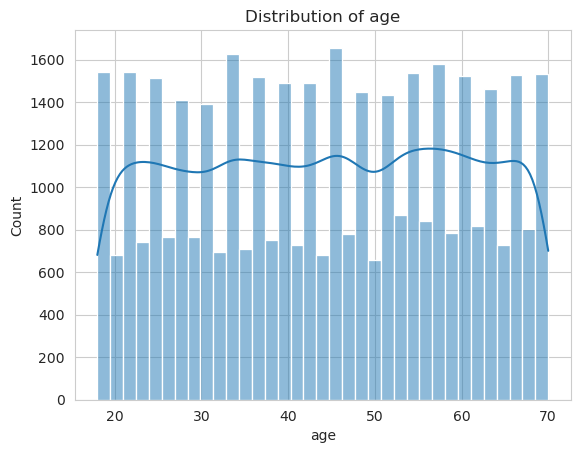

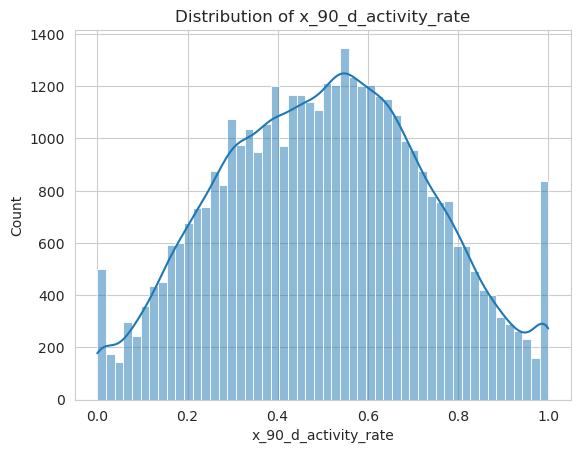

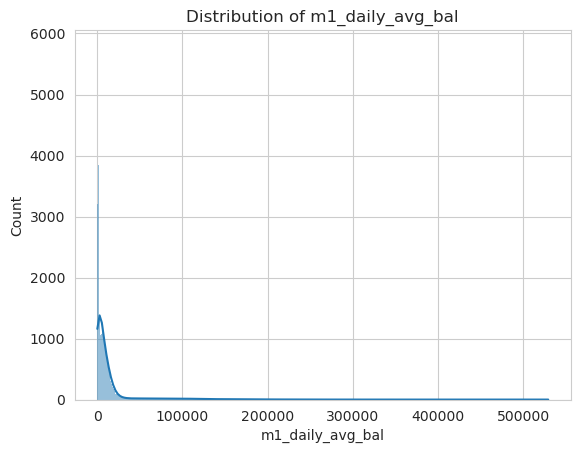

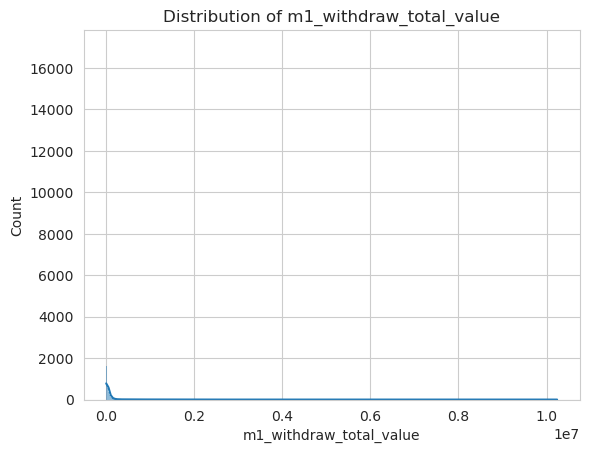

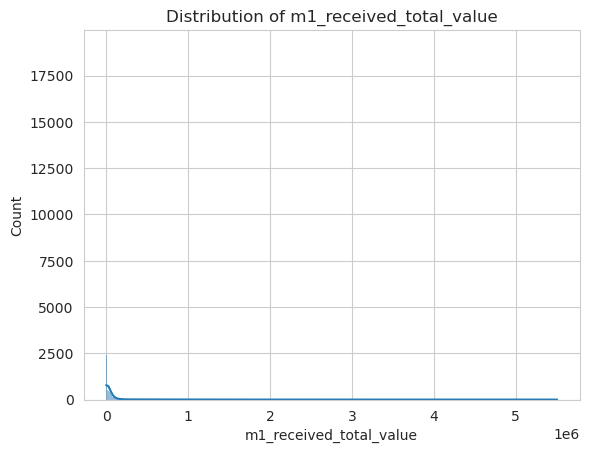

In [24]:
# Plot distributions of a few useful numeric features
num_features = [
    "arpu",
    "age",
    "x_90_d_activity_rate",
    "m1_daily_avg_bal",
    "m1_withdraw_total_value",
    "m1_received_total_value"
]

for col in num_features:
    if col in train.columns:
        sns.histplot(train[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()


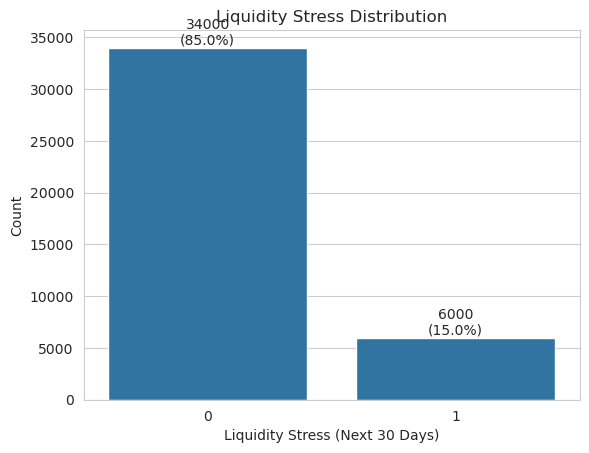

In [17]:
# Distribution of target variable
ax = sns.countplot(x=TARGET, data=train)
plt.title("Liquidity Stress Distribution")
plt.xlabel("Liquidity Stress (Next 30 Days)")
plt.ylabel("Count")

total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(f"{count}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.show()


### 🏷️ Encoding Categorical Variables

We use **one-hot encoding** to convert categorical columns into numeric format so they can be used by the model.


In [18]:
# Identify the ID column, target column and feature columns
TARGET = "liquidity_stress_next_30d"
ID_COL = "ID"

feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET]]
cat_cols = train[feature_cols].select_dtypes(include="object").columns.tolist()
num_cols = train[feature_cols].select_dtypes(include=["float64", "int64"]).columns.tolist()



In [95]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        )
    ]
)
model_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            penalty="elasticnet",
            l1_ratio=1.0,
            class_weight=None,
            solver="saga"
        ))
    ]
)
model_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [96]:
X = train[feature_cols]
y = train[TARGET]

In [97]:
splitter = StratifiedShuffleSplit(
    n_splits=4,
    test_size=0.2,
    random_state=42
)
splitter

StratifiedShuffleSplit(n_splits=4, random_state=42, test_size=0.2,
            train_size=None)

In [98]:
train_idx, val_idx = next(splitter.split(X, y))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]


In [99]:
model_pipeline.fit(X_train, y_train)
val_pred_prob = model_pipeline.predict_proba(X_val)[:,1]
print("Validation ROC-AUC:", roc_auc_score(y_val, val_pred_prob))

/home/bode-murairi/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Validation ROC-AUC: 0.7506495098039214


/home/bode-murairi/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [100]:
# Predict on validation set
from sklearn.metrics import log_loss
val_pred_prob = model_pipeline.predict_proba(X_val)[:, 1]
val_pred_label = (val_pred_prob >= 0.5).astype(int)

# Evaluate
print("Validation ROC-AUC:", roc_auc_score(y_val, val_pred_prob))
print("Validation Log Loss:", log_loss(y_val, val_pred_prob))
print("\nClassification Report:")
print(classification_report(y_val, val_pred_label))


Validation ROC-AUC: 0.7506495098039214
Validation Log Loss: 0.37757916521667073

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      6800
           1       0.53      0.06      0.11      1200

    accuracy                           0.85      8000
   macro avg       0.69      0.53      0.52      8000
weighted avg       0.81      0.85      0.80      8000



## 🧹 Preprocessing

We’ll split the training data into features and target, then create a validation set.


## 🤖 Model Training

We’ll use a Logistic Regression classifier as our baseline model.


In [101]:
def evaluation_metrics(y_val, val_pred_prob):
    val_log_loss = log_loss(y_val, val_pred_prob)
    val_roc_auc = roc_auc_score(y_val, val_pred_prob)
    combined_score = 0.6 * (1 - val_log_loss) + 0.4 * val_roc_auc   # higher = better
    return {
        "Validation Log Loss": val_log_loss,
        "Validation ROC-AUC": val_roc_auc,
        "Combined Score": combined_score
    }

In [102]:

# Predict on validation set
val_pred_prob = model_pipeline.predict_proba(X_val)[:, 1]
val_pred_label = (val_pred_prob >= 0.5).astype(int)

# Evaluate
val_evaluation = evaluation_metrics(y_val, val_pred_prob)
for name, value in val_evaluation.items():
    print(f"{name}: {value}")

print("\nClassification Report:")
print(classification_report(y_val, val_pred_label))


Validation Log Loss: 0.37757916521667073
Validation ROC-AUC: 0.7506495098039214
Combined Score: 0.6737123047915662

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      6800
           1       0.53      0.06      0.11      1200

    accuracy                           0.85      8000
   macro avg       0.69      0.53      0.52      8000
weighted avg       0.81      0.85      0.80      8000



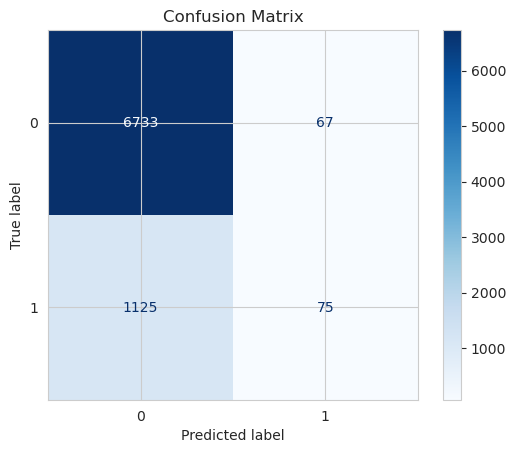

In [104]:
# 📈 Evaluate Model on Validation Set
cm = confusion_matrix(y_val, val_pred_label)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


### Attempt cross-validation to find best hyper-parameters for logistic regression

In [105]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, log_loss, roc_auc_score

def combined_score(y_true, y_pred_proba):
    ll = log_loss(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    return 0.6 * (1 - ll) + 0.4 * auc

In [106]:
model_pipeline.set_params(
    model__solver="saga",
    model__max_iter=2000,
    model__random_state=42
)
parameters = {
    "model__C": [0.01, 1, 10],
    "model__l1_ratio": np.arange(0, 1.01, 0.25).tolist(),
    "model__class_weight": ["balanced", None],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

combined_scorer = make_scorer(combined_score, response_method="predict_proba", greater_is_better=True)

random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=parameters,
    n_iter=5,
    scoring=combined_scorer,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

"""
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring=combined_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)
"""

'\ngrid_search = GridSearchCV(\n    estimator=model_pipeline,\n    param_grid=param_grid,\n    scoring=combined_scorer,\n    cv=cv,\n    n_jobs=-1,\n    verbose=1\n)\n'

In [107]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/home/bode-murairi/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bode-murairi/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bode-murairi/anaconda3/l

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.01, 1, ...], 'model__class_weight': ['balanced', None], 'model__l1_ratio': [0.0, 0.25, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(c...redict_proba')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be 

Exception ignored in: <function ResourceTracker.__del__ at 0x702108da4040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7799897a0040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception igno

In [108]:
print("Best params:", random_search.best_params_)
print("Best CV Combined Score:", random_search.best_score_)

best_model = random_search.best_estimator_
val_pred_prob = best_model.predict_proba(X_val)[:, 1]

val_evaluation = evaluation_metrics(y_val, val_pred_prob)
for name, value in val_evaluation.items():
    print(f"{name}: {value}")

Best params: {'model__l1_ratio': 0.5, 'model__class_weight': None, 'model__C': 1}
Best CV Combined Score: 0.674330775915997
Validation Log Loss: 0.37761078160288447
Validation ROC-AUC: 0.7507031862745097
Combined Score: 0.6737148055480733


## 📊 Optional: Feature Importance

This section gives a quick sense of which features are most useful to the baseline model. It is optional and can be skipped if you only want to generate a first submission quickly.


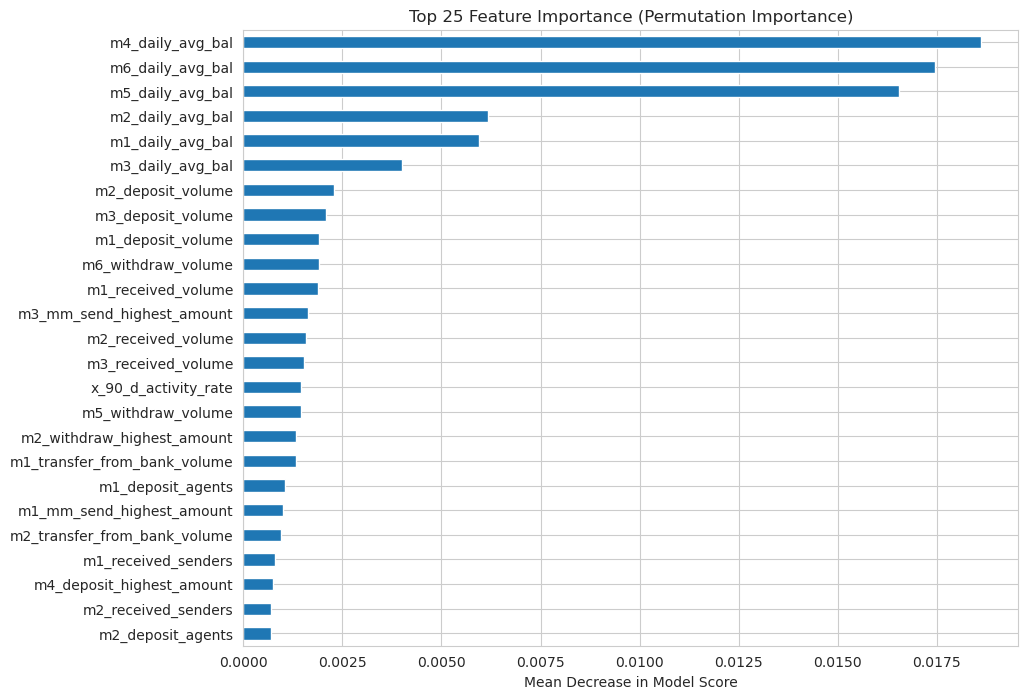

In [109]:
from sklearn.inspection import permutation_importance


result = permutation_importance(
    model_pipeline,
    X_val,
    y_val,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(result.importances_mean, index=X.columns)

(
    importances
    .sort_values(ascending=False)
    .head(25)
    .sort_values()
    .plot(kind="barh", figsize=(10,8))
)

plt.title("Top 25 Feature Importance (Permutation Importance)")
plt.xlabel("Mean Decrease in Model Score")
plt.show()


## 🚀 Predictions on Test Set

Let’s predict on the test set and generate a submission file.

The submission file must contain two columns:

- `ID`: the customer ID from the test set
- `Target`: the predicted probability that the customer will experience liquidity stress in the next 30 days

`Target` should be a probability between 0 and 1, not a hard class label.


In [110]:
# Retrain the model on the full training set
random_search.best_estimator_.fit(X, y)

/home/bode-murairi/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bode-murairi/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](182,)","['arpu','age','gender',...,'m4_daily_avg_bal','m5_daily_avg_bal', 'm6_daily_avg_bal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,182
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

In [111]:
# Predict probabilities on test data
test_predictions =  random_search.predict_proba(test[feature_cols])[:, 1]

In [112]:
# Prepare submission
submission = sample_submission.copy()
submission[SUBMISSION_TARGET] = test_predictions

# Save to CSV
submission.to_csv("submission.csv", index=False)
print("Submission file saved!")

submission.head()


Submission file saved!


,ID,Target
0,ID_ED91AC7A28,0.041577
1,ID_29975A9C7E,0.060335
2,ID_F59CE25650,0.040633
3,ID_E875F68D1A,0.008319
4,ID_2902B1C0D0,0.021152


## ✅ What’s Next?

This is just a baseline model. You are welcome to improve upon it or design your own pipeline from scratch!

Good luck, and happy modelling! 🚀
